In [1]:
# Execute from the repository root irrespective of the notebook frontend working directory.
import os
os.chdir('/home/ml/thesis-camels')


# Notebook 19 — Periodic-Invariant GNN: Validation Analysis and Optimization-Stability Diagnostic

**CAMELS-SIMBA · U1000 · Top1500 halos · final snapshot · validation-only saved-artifact analysis**

## Chronology: validation development, protocol closure, then one final protected evaluation

Model development and the split × training-RNG diagnostic used validation data only. The protected test set remained untouched until the experiment and evaluation rule were frozen. After protocol closure, exactly the three original predefined production runs were evaluated once on their corresponding protected test sets; no test result was used for development or selection.

This notebook reports a closed experiment. It does not train models, alter scientific artifacts, or perform protected-test inference or scoring.

## 1. Scientific motivation

The question is whether replacing frame-dependent raw halo positions and velocities with periodic, pairwise invariant quantities yields a robust graph neural network (GNN) for Omega_m regression. This is a physics-motivated invariant GNN, not a classical physics-informed neural network (PINN): it uses no differential-equation residual loss. Its physics-informed inductive bias is periodic geometry and relative spatial and kinematic information.

The original production trajectories showed strikingly different validation behavior. The analysis below therefore asks whether the variation is attributable primarily to split identity, training stochasticity, or their interaction.

## 2. Physics-motivated invariant graph representation

For a periodic box of side L = 25 h^-1 Mpc, directed kNN edges use k = 8 and the minimum-image displacement: Delta x_ij = x_i - x_j - L round((x_i - x_j)/L), with r_ij = norm(Delta x_ij).

With Delta v_ij = v_i - v_j, the edge inputs are r_ij/25, norm(Delta v_ij)/1000, and v_radial,ij/1000, where v_radial,ij = dot(Delta v_ij, Delta x_ij) / max(r_ij, epsilon). Nodes receive only log10(Mvir); absolute XYZ and VX/VY/VZ are not direct network inputs. The representation is invariant to common translations, periodic-box translations, common velocity boosts, and permutations through graph/set aggregation, as well as proper cube-frame transformations supported by these scalar quantities. It does not justify a claim of arbitrary SO(3) invariance on a wrapped periodic torus.

## 3. Frozen experiment protocol and provenance

The following preflight binds this notebook to the closed, validation-only artifacts. Any changed artifact stops execution.

In [2]:
from pathlib import Path
import hashlib, json, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT = Path.cwd().resolve()
if not (ROOT / 'reports').exists(): ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
def sha(path): return hashlib.sha256(Path(path).read_bytes()).hexdigest()
registry = ROOT / 'reports/experiment_registry'
expected = {
 'u1000_top1500_periodic_invariant_gnn_protocol_freeze.json':'edff75346e61070735eeb9cae5d404d9827338f695835c139e9db37a19a1cbf6',
 'u1000_top1500_periodic_invariant_gnn_implementation_freeze.json':'139afbdde8f5402a9be861af4d56adff8644e9843c7fa8a0d250089470ad3654',
 'u1000_top1500_periodic_invariant_gnn_validation_training_freeze.json':'97bb9c404f82c3f0ad860df28ba5b0f3f5e42872231aecdfe1b3fd6c7b482be8',
 'u1000_top1500_periodic_invariant_gnn_split_rng_diagnostic_implementation_freeze.json':'4f3010d3a8fa08002d36f31b4a058efc7eb18df6e57e47776b8548fa7d2b8057',
 'u1000_top1500_periodic_invariant_gnn_split_rng_diagnostic_result_freeze.json':'3cb17cedc30f01f1f97b8a4fda52d287d29116f30c1fd813015c4963e02ddcf7'}
for name, digest in expected.items(): assert sha(registry/name) == digest, f'changed freeze: {name}'
dataset = ROOT/'data/processed/temporal_1000u_none_top1500_periodic_knn_sparse/camels_1000u_temporal_logmass_none_top1500_periodic_knn_sparse.pt'
assert sha(dataset) == 'ff6f6a89517c0b67a96a8733ce5778dba1524df441cc23c27fbfa4e2f5cdb113'
result = json.loads((registry/'u1000_top1500_periodic_invariant_gnn_split_rng_diagnostic_result_freeze.json').read_text())
protocol = json.loads((registry/'u1000_top1500_periodic_invariant_gnn_protocol_freeze.json').read_text())
print('Provenance preflight passed: five freezes and frozen dataset match expected SHA256 values.')
display(pd.DataFrame([['Dataset','CAMELS-SIMBA U1000; 1000 universes'],['Partitions','700 train / 99 validation / 201 protected test'],['Halo selection / snapshot','Top1500 / final'],['Target','Omega_m'],['Graph','periodic kNN, k=8; L=25 h^-1 Mpc'],['Node / edge features','log10(Mvir); r/25, relative speed/1000, radial velocity/1000'],['Architecture','hidden 17; 3 incoming-mean message layers; mean pooling'],['Regularization','dropout 0.2; clip norm 1.0'],['Training','AdamW, lr 1e-3, wd 1e-5; MSE; batch 8; max 300 epochs'],['Scheduler / stopping','ReduceLROnPlateau factor 0.5, patience 10, min LR 1e-6; early stop 40'],['Trainable parameters','5270'],['Protected test','NOT EVALUATED']], columns=['Protocol field','Frozen value']))

Provenance preflight passed: five freezes and frozen dataset match expected SHA256 values.


,Protocol field,Frozen value
0,Dataset,CAMELS-SIMBA U1000; 1000 universes
1,Partitions,700 train / 99 validation / 201 protected test
2,Halo selection / snapshot,Top1500 / final
3,Target,Omega_m
4,Graph,"periodic kNN, k=8; L=25 h^-1 Mpc"
5,Node / edge features,"log10(Mvir); r/25, relative speed/1000, radial..."
6,Architecture,hidden 17; 3 incoming-mean message layers; mea...
7,Regularization,dropout 0.2; clip norm 1.0
8,Training,"AdamW, lr 1e-3, wd 1e-5; MSE; batch 8; max 300..."
9,Scheduler / stopping,"ReduceLROnPlateau factor 0.5, patience 10, min..."


## 4. Original production results

The predefined production diagonal is retained as the official result; it is not replaced by a diagnostic-grid average.

,split seed,best epoch,validation MAE,validation MSE,R2,prediction spread ratio,collapse classification
0,42,7,0.09895,0.01234,0.02436,0.01484,severe collapse
4,123,155,0.03539,0.00194,0.85653,0.93633,healthy learning
8,2025,5,0.10355,0.01404,-0.00008,0.00000,complete collapse


Official original production validation MAE = 0.07930 ± 0.03809 (sample SD; validation only).


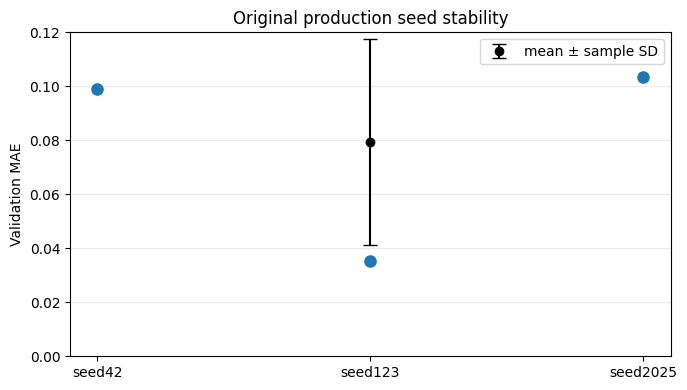

In [3]:
cells = pd.DataFrame([{**{'split seed':c['split_seed'],'training RNG':c['training_rng_seed'],'role':c['role'],'best epoch':c['best_epoch'],'validation MAE':c['validation']['mae'],'validation MSE':c['validation']['mse'],'RMSE':c['validation']['rmse'],'R2':c['validation']['r2'],'prediction spread ratio':c['spread_ratio'],'calibration slope':c['calibration_slope'],'collapse classification':c['collapse_label'],'run path':c['run_path']}} for c in result['cells']])
original = cells.query('`split seed` == `training RNG`').sort_values('split seed')
display(original[['split seed','best epoch','validation MAE','validation MSE','R2','prediction spread ratio','collapse classification']].style.format(precision=5))
maes=original['validation MAE'].to_numpy(); print(f'Official original production validation MAE = {maes.mean():.5f} ± {maes.std(ddof=1):.5f} (sample SD; validation only).')
fig, ax=plt.subplots(figsize=(7,4)); x=np.arange(3); ax.scatter(x,maes,s=65,color='tab:blue',zorder=3); ax.errorbar([1],[maes.mean()],yerr=[maes.std(ddof=1)],fmt='o',color='black',capsize=5,label='mean ± sample SD'); ax.set_xticks(x,['seed42','seed123','seed2025']); ax.set_ylim(0, max(.12,maes.max()*1.15)); ax.set_ylabel('Validation MAE'); ax.set_title('Original production seed stability'); ax.grid(axis='y',alpha=.25); ax.legend(); fig.tight_layout(); plt.show()

## 5. Diagnosing prediction collapse

Prediction-spread ratio is std(predicted Omega_m) / std(true Omega_m). Values near zero indicate severe output compression toward a mean-like prediction; values nearer one recover the target dynamic range. This diagnostic alone does not determine accuracy.

In [4]:
# Frozen-checkpoint replay; validation IDs only, with explicit protected-test exclusion.
import torch
from torch.utils.data import DataLoader
from src.training.train_periodic_invariant_gnn import _Dataset, _collate, _final_samples
from src.training.split_manifest import load_split_manifest
from src.training.sparse_batch import sparse_batch_to
from src.data.periodic_invariant_features import periodic_invariant_features
from src.models.periodic_invariant_gnn import PeriodicInvariantGNNRegressor
raw=torch.load(dataset, map_location='cpu', weights_only=False); samples=_final_samples(raw); device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def replay(split_seed, rng_seed):
    row=cells.query('`split seed`==@split_seed and `training RNG`==@rng_seed').iloc[0]
    meta=json.loads((ROOT/row['run path']/'metadata.json').read_text()); manifest_path=ROOT/meta['split_manifest_path']
    manifest=load_split_manifest(manifest_path, sorted(samples), sha(dataset), expected_seed=int(split_seed))
    val_ids=list(manifest['val_ids']); test_ids=set(manifest['test_ids'])
    assert len(val_ids)==99 and len(val_ids)==len(set(val_ids)) and not(set(val_ids)&test_ids)
    loader=DataLoader(_Dataset(samples,val_ids),batch_size=8,shuffle=False,collate_fn=_collate)
    model=PeriodicInvariantGNNRegressor().to(device); ck=torch.load(ROOT/row['run path']/'best_validation_checkpoint.pt',map_location=device,weights_only=False); model.load_state_dict(ck['model_state_dict']); model.eval(); ids=[]; pred=[]; true=[]
    with torch.no_grad():
      for batch_ids, graph, target in loader:
       graph=sparse_batch_to(graph,device); node,edge=periodic_invariant_features(graph['x'],graph['edge_index']); out=model(node,graph['edge_index'],edge,graph['batch'],graph['num_graphs']).cpu().view(-1).numpy(); ids += batch_ids; pred.extend(out); true.extend(target.view(-1).numpy())
    assert ids==val_ids and len(ids)==99 and not(set(ids)&test_ids) and np.isfinite(pred).all()
    y=np.asarray(true); p=np.asarray(pred); mse=np.mean((p-y)**2); out={'ids':ids,'true':y,'pred':p,'MAE':np.mean(abs(p-y)),'R2':1-np.sum((p-y)**2)/np.sum((y-y.mean())**2),'spread':p.std()/y.std()}
    for key, frozen in [('MAE',row['validation MAE']),('R2',row['R2']),('spread',row['prediction spread ratio'])]: assert np.isclose(out[key],frozen,rtol=2e-5,atol=2e-6), f'replay mismatch {split_seed}/{rng_seed}: {key}'
    return out
replays={(123,123):replay(123,123),(123,2025):replay(123,2025),(42,42):replay(42,42),(2025,2025):replay(2025,2025)}
display(pd.DataFrame([{'cell':f'{s}/{r}','validation predictions':len(v['ids']),'MAE':v['MAE'],'R2':v['R2'],'spread ratio':v['spread'],'frozen match':'yes'} for (s,r),v in replays.items()]).style.format(precision=5))

,cell,validation predictions,MAE,R2,spread ratio,frozen match
0,123/123,99,0.03539,0.85653,0.93633,yes
1,123/2025,99,0.06561,0.57360,0.43096,yes
2,42/42,99,0.09895,0.02436,0.01484,yes
3,2025/2025,99,0.10355,-0.00008,0.00000,yes


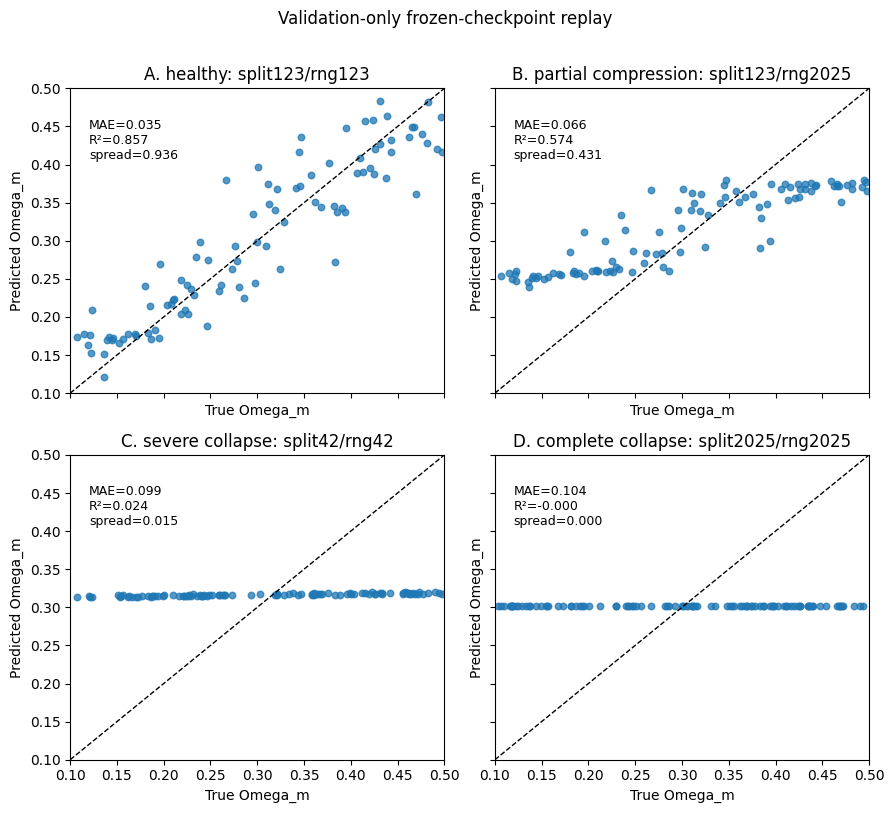

In [5]:
fig,axs=plt.subplots(2,2,figsize=(9,8),sharex=True,sharey=True); lim=(.1,.5)
for ax,((s,r),v),title in zip(axs.flat,replays.items(),['A. healthy: split123/rng123','B. partial compression: split123/rng2025','C. severe collapse: split42/rng42','D. complete collapse: split2025/rng2025']):
 ax.scatter(v['true'],v['pred'],s=22,alpha=.75); ax.plot(lim,lim,'k--',lw=1); ax.set(title=title,xlim=lim,ylim=lim); ax.text(.12,.46,f"MAE={v['MAE']:.3f}\nR²={v['R2']:.3f}\nspread={v['spread']:.3f}",va='top',fontsize=9); ax.set_xlabel('True Omega_m'); ax.set_ylabel('Predicted Omega_m')
fig.suptitle('Validation-only frozen-checkpoint replay',y=1.01); fig.tight_layout(); plt.show()

## 6. Split × training-RNG diagnostic design

The original diagonal confounded split42/rng42, split123/rng123, and split2025/rng2025. Six validation-only off-diagonal runs form a complete $3\times3$ factorial grid. `--seed` denotes immutable split identity, while `--training-rng-seed` controls the joint Python, NumPy, PyTorch CPU/CUDA, initialization, shuffled DataLoader, and dropout trajectory. Thus the diagnostic establishes sensitivity to optimization/training stochasticity; it does **not** isolate initialization from shuffle or dropout individually.

## 7. Nine-cell validation results


,split seed,training RNG,role,best epoch,validation MAE,validation MSE,RMSE,R2,prediction spread ratio,calibration slope,collapse classification
0,42,42,original_production,7,0.09895,0.01234,0.11108,0.02436,0.01484,0.01313,severe collapse
1,42,123,diagnostic_validation_only,23,0.09212,0.01096,0.10467,0.13366,0.10650,0.09487,severe collapse
2,42,2025,diagnostic_validation_only,26,0.09145,0.01128,0.10622,0.10795,0.18637,0.12224,partial compression
3,123,42,diagnostic_validation_only,4,0.10149,0.01351,0.11622,0.00299,0.01180,0.01087,severe collapse
4,123,123,original_production,155,0.03539,0.00194,0.04409,0.85653,0.93633,0.86786,healthy learning
5,123,2025,diagnostic_validation_only,18,0.06561,0.00578,0.07600,0.57360,0.43096,0.38475,partial compression
6,2025,42,diagnostic_validation_only,1,0.10304,0.01399,0.11829,0.00348,0.00231,0.00204,severe collapse
7,2025,123,diagnostic_validation_only,44,0.05891,0.00522,0.07226,0.62807,0.88210,0.79669,healthy learning
8,2025,2025,original_production,5,0.10355,0.01404,0.11850,-0.00008,0.00000,-0.00000,complete collapse


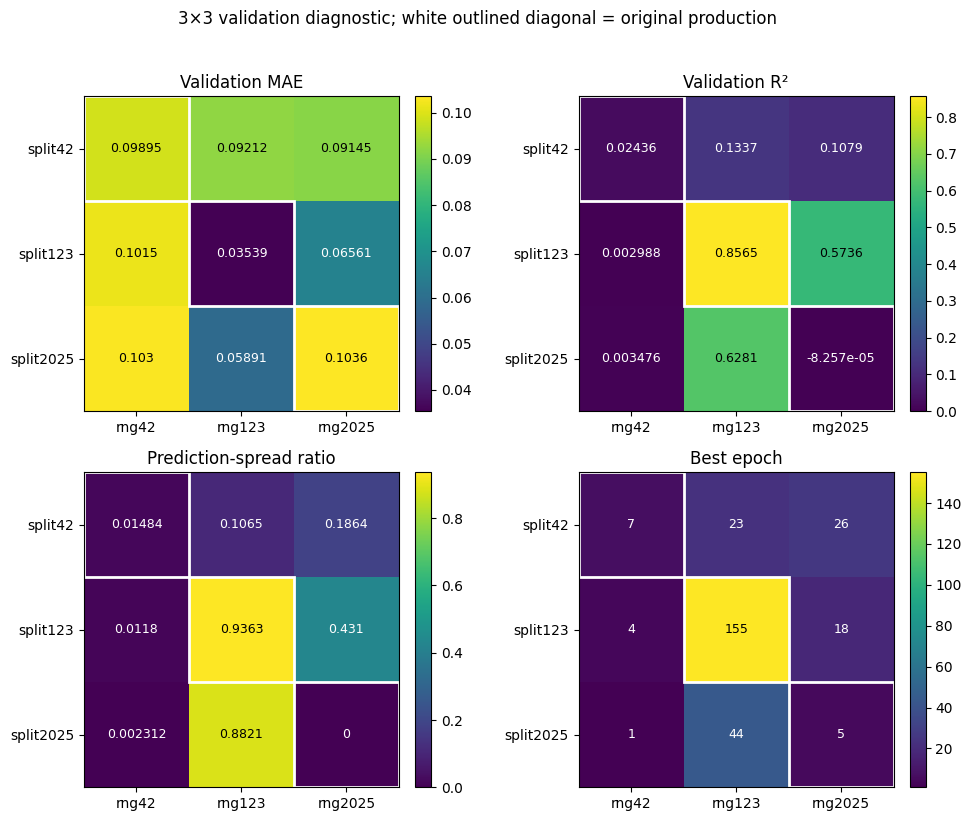

In [6]:
display(cells.drop(columns='run path').sort_values(['split seed','training RNG']).style.format(precision=5))
seeds=[42,123,2025]
def matrix(col): return cells.pivot(index='split seed',columns='training RNG',values=col).loc[seeds,seeds]
fig,axs=plt.subplots(2,2,figsize=(10,8)); specs=[('validation MAE','Validation MAE'),('R2','Validation R²'),('prediction spread ratio','Prediction-spread ratio'),('best epoch','Best epoch')]
for ax,(col,title) in zip(axs.flat,specs):
 m=matrix(col); im=ax.imshow(m,cmap='viridis'); ax.set(xticks=range(3),xticklabels=[f'rng{x}' for x in seeds],yticks=range(3),yticklabels=[f'split{x}' for x in seeds],title=title)
 for i in range(3):
  for j in range(3): ax.text(j,i,f'{m.iloc[i,j]:.4g}',ha='center',va='center',color='white' if im.norm(m.iloc[i,j])<.5 else 'black',fontsize=9); ax.add_patch(plt.Rectangle((i-.5,i-.5),1,1,fill=False,edgecolor='white',lw=2) if i==j else plt.Rectangle((9,9),0,0,fill=False))
 fig.colorbar(im,ax=ax,fraction=.046,pad=.04)
fig.suptitle('3×3 validation diagnostic; white outlined diagonal = original production',y=1.02); fig.tight_layout(); plt.show()

## 8. Optimization behavior

Frozen epoch histories are plotted, without retraining, to assess whether collapsed trajectories learned and then overfit or instead selected early, compressed solutions.

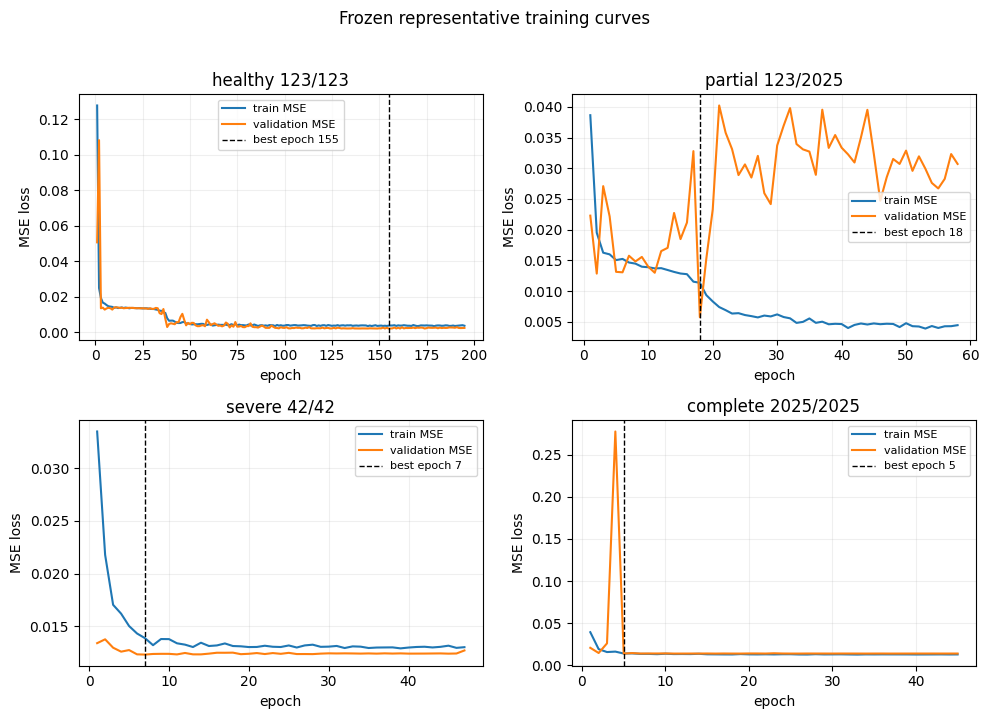

Collapsed runs select very early checkpoints and show strong prediction compression. This is more consistent with optimization/underfitting collapse than classic late-stage overfitting, without establishing a causal mechanism.

In [7]:
fig,axs=plt.subplots(2,2,figsize=(10,7)); titles=['healthy 123/123','partial 123/2025','severe 42/42','complete 2025/2025']
for ax,((s,r),title) in zip(axs.flat,zip(replays,titles)):
 row=cells.query('`split seed`==@s and `training RNG`==@r').iloc[0]; h=pd.read_csv(ROOT/row['run path']/'epoch_metrics.csv'); ax.plot(h.epoch,h.train_mse,label='train MSE'); ax.plot(h.epoch,h.validation_mse,label='validation MSE'); best=int(row['best epoch']); ax.axvline(best,color='k',ls='--',lw=1,label=f'best epoch {best}'); ax.set(title=title,xlabel='epoch',ylabel='MSE loss'); ax.legend(fontsize=8); ax.grid(alpha=.2)
fig.suptitle('Frozen representative training curves',y=1.02); fig.tight_layout(); plt.show()
display(Markdown('Collapsed runs select very early checkpoints and show strong prediction compression. This is more consistent with optimization/underfitting collapse than classic late-stage overfitting, without establishing a causal mechanism.'))

## 9. RNG effect versus split effect


**Across training RNG**

,mean,sample SD
training RNG,,
42,0.101160,0.002065
123,0.062140,0.028500
2025,0.086870,0.019385


**Across split**

,mean,sample SD
split seed,,
42,0.094172,0.004150
123,0.067497,0.033090
2025,0.088501,0.025628


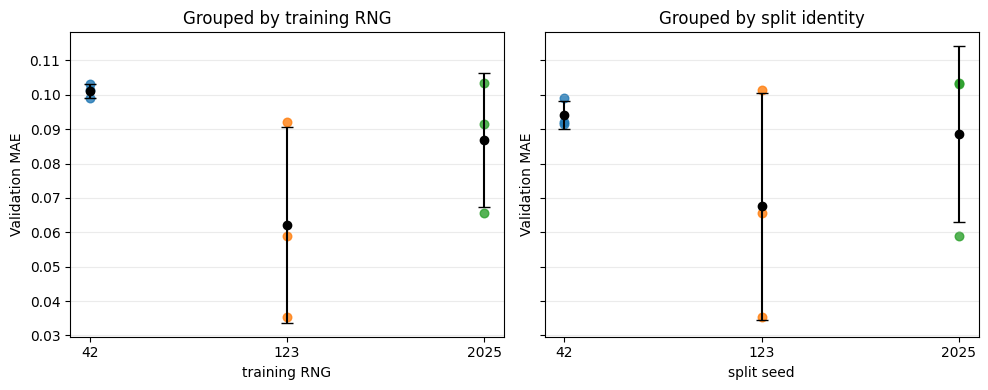

In [8]:
def summary(group): return cells.groupby(group)['validation MAE'].agg(['mean','std']).rename(columns={'std':'sample SD'})
display(Markdown('**Across training RNG**')); display(summary('training RNG').style.format(precision=6)); display(Markdown('**Across split**')); display(summary('split seed').style.format(precision=6))
fig,axs=plt.subplots(1,2,figsize=(10,4),sharey=True)
for ax,group,title in zip(axs,['training RNG','split seed'],['Grouped by training RNG','Grouped by split identity']):
 vals=cells.groupby(group); keys=list(vals.groups);
 for i,k in enumerate(keys):
  y=vals.get_group(k)['validation MAE']; ax.scatter(np.full(len(y),i),y,s=38,alpha=.8); ax.errorbar(i,y.mean(),yerr=y.std(ddof=1),fmt='o',color='black',capsize=4)
 ax.set(xticks=range(len(keys)),xticklabels=[str(k) for k in keys],xlabel=group,ylabel='Validation MAE',title=title); ax.grid(axis='y',alpha=.25)
fig.tight_layout(); plt.show()

## 10. Relationship between output compression and predictive performance


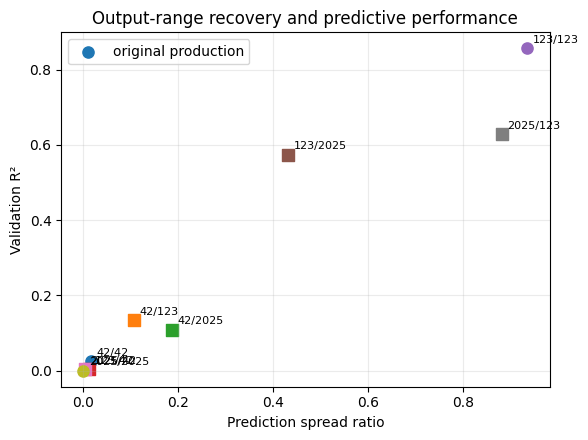

Healthy cells occupy the high-spread/high-$R^2$ region, while collapsed cells have near-zero spread and near-zero $R^2$. With nine cells this descriptive pattern is not a causal correlation claim.

In [9]:
fig,ax=plt.subplots(figsize=(6,4.5))
for _,q in cells.iterrows():
 diag=q['split seed']==q['training RNG']; ax.scatter(q['prediction spread ratio'],q['R2'],s=65,marker='o' if diag else 's',label='original production' if diag and not any(ax.get_legend_handles_labels()[1]) else None); ax.annotate(f"{q['split seed']}/{q['training RNG']}",(q['prediction spread ratio'],q['R2']),xytext=(4,4),textcoords='offset points',fontsize=8)
ax.set(xlabel='Prediction spread ratio',ylabel='Validation R²',title='Output-range recovery and predictive performance'); ax.grid(alpha=.25); ax.legend(); fig.tight_layout(); plt.show()
display(Markdown('Healthy cells occupy the high-spread/high-$R^2$ region, while collapsed cells have near-zero spread and near-zero $R^2$. With nine cells this descriptive pattern is not a causal correlation claim.'))

## 11. Matched Static GCN comparison

Only the predefined invariant production diagonal is compared with the matched Static GCN validation values; no off-diagonal diagnostic cell is selected as production performance.

,Static GCN validation MAE,Original invariant-GNN validation MAE
42,0.036552,0.098948
123,0.041268,0.035394
2025,0.036248,0.103554


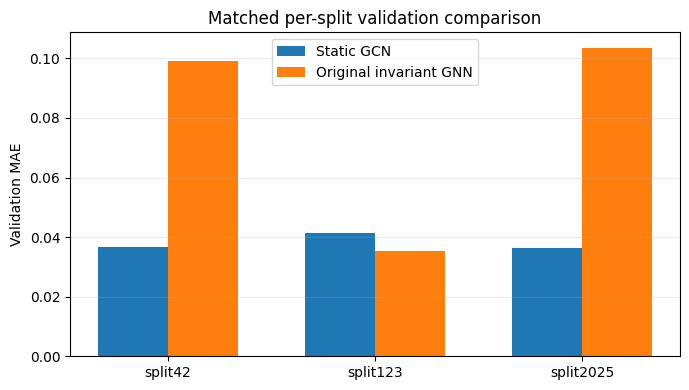

Static GCN is clearly lower-MAE on splits 42 and 2025; the invariant GNN is slightly lower on split 123. This is not a winner claim across non-equivalent model families.

In [10]:
static=pd.Series({42:.036552,123:.041268,2025:.036248}); invariant=original.set_index('split seed')['validation MAE']; comp=pd.DataFrame({'Static GCN validation MAE':static,'Original invariant-GNN validation MAE':invariant}); display(comp.style.format(precision=6))
fig,ax=plt.subplots(figsize=(7,4)); x=np.arange(3); w=.34; ax.bar(x-w/2,static.values,w,label='Static GCN'); ax.bar(x+w/2,invariant.values,w,label='Original invariant GNN'); ax.set(xticks=x,xticklabels=[f'split{s}' for s in seeds],ylabel='Validation MAE',title='Matched per-split validation comparison'); ax.legend(); ax.grid(axis='y',alpha=.25); fig.tight_layout(); plt.show()
display(Markdown('Static GCN is clearly lower-MAE on splits 42 and 2025; the invariant GNN is slightly lower on split 123. This is not a winner claim across non-equivalent model families.'))

## 12. Broader model context

These authoritative validation summaries provide context only. Models are not all input-matched: temporal GCN-GRU uses multiple snapshots whereas this invariant GNN uses only the final snapshot.

In [11]:
context=pd.DataFrame([['Gradient Boosting',.008414,.000564],['Random Forest',.009587,.000884],['CNN3D',.018617,.000417],['GCN-GRU',.028065,.002001],['Static GCN',.038023,.002815],['Periodic-Invariant GNN (original production)',maes.mean(),maes.std(ddof=1)]],columns=['Model','validation MAE mean','sample SD'])
display(context.style.format(precision=6)); print('Sources verified in repository: temporal_five_model validation report and prior frozen notebook/report artifacts for the tabulated validation summaries.')

,Model,validation MAE mean,sample SD
0,Gradient Boosting,0.008414,0.000564
1,Random Forest,0.009587,0.000884
2,CNN3D,0.018617,0.000417
3,GCN-GRU,0.028065,0.002001
4,Static GCN,0.038023,0.002815
5,Periodic-Invariant GNN (original production),0.079299,0.038093


Sources verified in repository: temporal_five_model validation report and prior frozen notebook/report artifacts for the tabulated validation summaries.


## 13. Scientific diagnosis


In [12]:
diagnosis=pd.DataFrame([['Implementation bug','Healthy high-R² cells use frozen implementation','No direct proof either way','Little direct evidence'],['Bad split','split42 is poor for all three RNGs','split123/2025 can also collapse','Secondary; split42 vulnerable'],['Training-RNG / optimization sensitivity','rng42 collapses on all splits; rng123 is healthy twice','Only three RNG values','Strongest evidence; primary'],['Underfitting','Collapsed cells select very early, compressed outputs','Healthy cells learn well','Description of collapsed cells'],['Overfitting','None as primary','Early selection, not late degradation','Not primary'],['Representation incapable','123/123 and 2025/123 have high R²','Recipe is not robust','Unsupported'],['Architecture / training recipe fragility','Large variation under fixed recipe','No component ablation','Supported'],['Split × RNG interaction','same RNG differs across splits','Small 3×3 grid','Secondary interaction supported']],columns=['Hypothesis','Evidence supporting','Evidence against','Current interpretation']); display(diagnosis)
display(Markdown('The diagnostic demonstrates **optimization/training stochasticity instability**, not that initialization alone is proven causal: the training RNG jointly changes initialization, shuffling, dropout, and other stochastic behavior.'))

,Hypothesis,Evidence supporting,Evidence against,Current interpretation
0,Implementation bug,Healthy high-R² cells use frozen implementation,No direct proof either way,Little direct evidence
1,Bad split,split42 is poor for all three RNGs,split123/2025 can also collapse,Secondary; split42 vulnerable
2,Training-RNG / optimization sensitivity,rng42 collapses on all splits; rng123 is healt...,Only three RNG values,Strongest evidence; primary
3,Underfitting,"Collapsed cells select very early, compressed ...",Healthy cells learn well,Description of collapsed cells
4,Overfitting,None as primary,"Early selection, not late degradation",Not primary
5,Representation incapable,123/123 and 2025/123 have high R²,Recipe is not robust,Unsupported
6,Architecture / training recipe fragility,Large variation under fixed recipe,No component ablation,Supported
7,Split × RNG interaction,same RNG differs across splits,Small 3×3 grid,Secondary interaction supported


The diagnostic demonstrates **optimization/training stochasticity instability**, not that initialization alone is proven causal: the training RNG jointly changes initialization, shuffling, dropout, and other stochastic behavior.

## Final Protected-Test Evaluation

**Phase 1** used validation-only development and diagnosis. **Phase 2** froze the protocol and committed the final-test decision before access. **Phase 3** evaluated only split42/rng42, split123/rng123, and split2025/rng2025 exactly once. The six off-diagonal diagnostic cells were never tested, and no post-test model tuning is permitted. The factorial split × RNG grid remains a validation diagnostic, not a test-selection grid.

In [13]:
# Read finalized protected artifacts only; do not invoke inference or training here.
final_decision_path = registry/'u1000_top1500_periodic_invariant_gnn_final_test_decision_freeze.json'
final_result_path = registry/'u1000_top1500_periodic_invariant_gnn_final_test_result_freeze.json'
assert sha(final_decision_path) == '4cac9e04768f33a7a5b557099cb5b8461500e9547eb980c1aa42dd4ab263f887'
assert sha(final_result_path) == '9453b8df01b70e5bd324f4c07398a804f2d7d9b405684dc7a1426c08d24b740a'
final_result=json.loads(final_result_path.read_text()); assert final_result['protected_test_evaluated'] and not final_result['diagnostic_off_diagonal_test_evaluated'] and final_result['no_further_tuning_permitted']
test_rows=[]; test_predictions={}
for cell in final_result['production_cells']:
    m=cell['metrics']; run=ROOT/cell['run_path']; pred=pd.read_csv(run/'test_predictions.csv')
    assert len(pred)==201 and pred.universe_id.is_unique and np.isfinite(pred[['true_omega_m','pred_omega_m']].to_numpy()).all()
    assert sha(run/'test_predictions.csv')==cell['artifacts']['test_predictions_sha256']
    test_predictions[cell['split_seed']]=pred
    test_rows.append({'split seed':cell['split_seed'],'training RNG':cell['training_rng_seed'],'best validation epoch':int(cells.query('`split seed`==@cell["split_seed"] and `training RNG`==@cell["training_rng_seed"]')['best epoch'].iloc[0]),'validation MAE':float(cells.query('`split seed`==@cell["split_seed"] and `training RNG`==@cell["training_rng_seed"]')['validation MAE'].iloc[0]),'test MAE':m['mae'],'test MSE':m['mse'],'test RMSE':m['rmse'],'test R2':m['r2'],'test spread ratio':m['spread_ratio'],'role':'original production'})
test_table=pd.DataFrame(test_rows).sort_values('split seed'); display(test_table.style.format(precision=5))
for metric in ('mae','mse','rmse','r2'):
    a=final_result['aggregate_metrics'][metric]; print(f'Final test {metric.upper()} = {a["mean"]:.5f} ± {a["sample_sd"]:.5f} (mean ± sample SD; three predefined seeds)')

,split seed,training RNG,best validation epoch,validation MAE,test MAE,test MSE,test RMSE,test R2,test spread ratio,role
0,42,42,7,0.09895,0.10288,0.01430,0.11959,0.02442,0.01565,original production
1,123,123,155,0.03539,0.03247,0.00166,0.04073,0.87261,0.95506,original production
2,2025,2025,5,0.10355,0.10585,0.01450,0.12042,-0.00072,0.00000,original production


Final test MAE = 0.08040 ± 0.04153 (mean ± sample SD; three predefined seeds)
Final test MSE = 0.01015 ± 0.00736 (mean ± sample SD; three predefined seeds)
Final test RMSE = 0.09358 ± 0.04577 (mean ± sample SD; three predefined seeds)
Final test R2 = 0.29877 ± 0.49712 (mean ± sample SD; three predefined seeds)


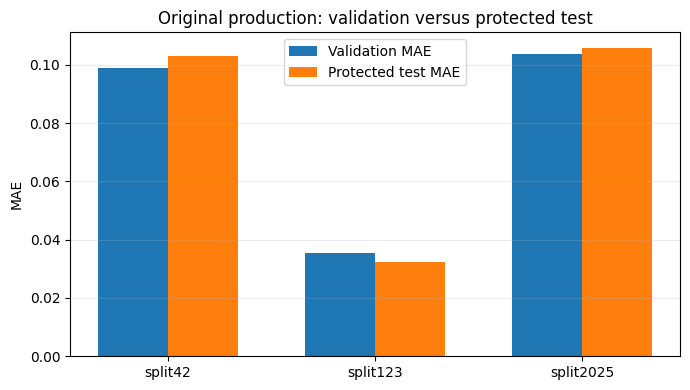

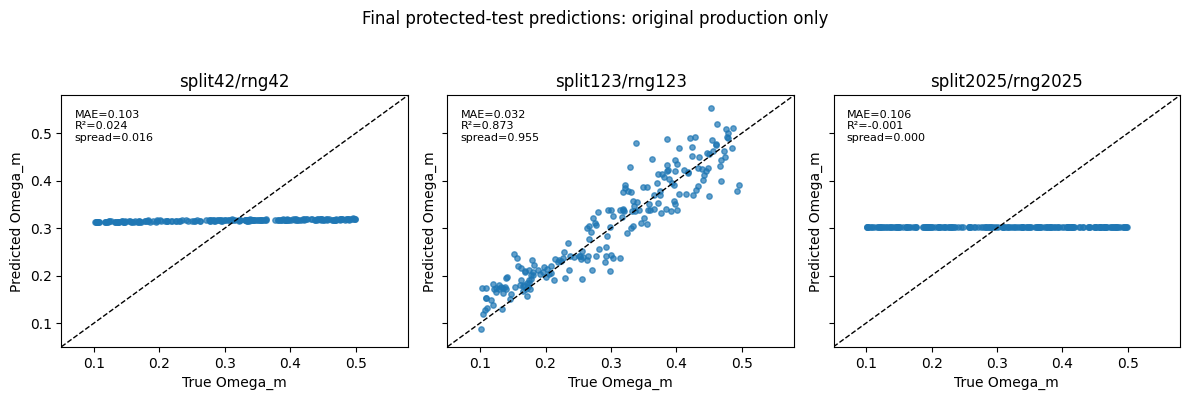

In [14]:
fig,ax=plt.subplots(figsize=(7,4)); x=np.arange(3); w=.34
ax.bar(x-w/2,test_table['validation MAE'],w,label='Validation MAE'); ax.bar(x+w/2,test_table['test MAE'],w,label='Protected test MAE')
ax.set(xticks=x,xticklabels=[f'split{s}' for s in test_table['split seed']],ylabel='MAE',title='Original production: validation versus protected test'); ax.grid(axis='y',alpha=.25); ax.legend(); fig.tight_layout(); plt.show()
fig,axs=plt.subplots(1,3,figsize=(12,3.8),sharex=True,sharey=True); lim=(.05,.58)
for ax,(_,q) in zip(axs,test_table.iterrows()):
    p=test_predictions[q['split seed']]; ax.scatter(p.true_omega_m,p.pred_omega_m,s=15,alpha=.7); ax.plot(lim,lim,'k--',lw=1); ax.set(title=f"split{int(q['split seed'])}/rng{int(q['training RNG'])}",xlim=lim,ylim=lim,xlabel='True Omega_m',ylabel='Predicted Omega_m'); ax.text(.07,.55,f"MAE={q['test MAE']:.3f}\nR²={q['test R2']:.3f}\nspread={q['test spread ratio']:.3f}",va='top',fontsize=8)
fig.suptitle('Final protected-test predictions: original production only',y=1.04); fig.tight_layout(); plt.show()

## Updated final conclusion

The validation diagnosis remains that the periodic-invariant GNN recipe is strongly sensitive to training stochasticity, with secondary split × RNG interaction. The final protected evaluation, fixed before access, gives test MAE **0.08040 ± 0.04153** across the three original production seeds. The held-out results are heterogeneous: split123/rng123 generalizes strongly, while split42/rng42 and split2025/rng2025 remain severely compressed. Thus the final test corroborates weak and unstable generalization of the current recipe. These results close this experiment family; they do not authorize seed selection, retuning, or a new experiment.

## Final protected-test reproducibility and status

Final-test decision freeze: `reports/experiment_registry/u1000_top1500_periodic_invariant_gnn_final_test_decision_freeze.json` (SHA256 `4cac9e04768f33a7a5b557099cb5b8461500e9547eb980c1aa42dd4ab263f887`; commit `0692d0c4fe253d6a4789345156799e56af43b2e6`). Final-test result freeze: `reports/experiment_registry/u1000_top1500_periodic_invariant_gnn_final_test_result_freeze.json` (SHA256 `9453b8df01b70e5bd324f4c07398a804f2d7d9b405684dc7a1426c08d24b740a`). Each original checkpoint produced 201 protected objects; their canonical protected-output hashes are recorded in the result freeze.

# PROTECTED TEST SET ACCESSED = YES — FINAL EVALUATION ONLY, AFTER PROTOCOL FREEZE

# DIAGNOSTIC OFF-DIAGONAL TEST SET ACCESSED = NO

# NO POST-TEST MODEL TUNING PERMITTED

## 14. Limitations

Only three split seeds and three training-RNG values were examined, so no formal significance inference follows. Training RNG bundles multiple stochastic mechanisms. The model is final-snapshot-only with fixed mean message aggregation and mean graph pooling; its intentionally compressed invariant representation differs from raw7. Protected test remains untouched, and temporal comparisons are contextual rather than input-matched.

## 15. Final conclusions

The periodic-invariant representation removes dependence on arbitrary absolute coordinate and velocity frames while retaining relative spatial and kinematic halo information. Successful validation trajectories show that it contains meaningful Omega_m information, but the current architecture/training recipe is highly unstable. The split-by-training-RNG diagnostic identifies optimization stochasticity as the dominant source of variation, with additional split-dependent interaction. Accordingly, this periodic-invariant GNN cannot presently be claimed as a robust improvement over the conventional Static GCN. This does not establish that physically motivated invariance is inherently harmful; it constrains this particular representation, architecture, and training recipe.

## 16. Reproducibility and test-protection statement

Repository branch: `thesis-notebook19-physics-informed-invariant-gnn`. Starting commit: `404414184410e482e3be7e3d526fb8a1bf449699`. This notebook verifies the protocol, implementation, validation-training, diagnostic-implementation, and diagnostic-result freezes; the dataset SHA256; split-manifest identities; and replay checkpoint results. All invariant-GNN results here are validation-only.

# Historical validation phase: TEST SET ACCESSED = NO

The current final status is stated in the final protected-test section below.

In [15]:
# Final safety assertion: every actual inference ID was a validation ID and never a protected-test ID.
assert all(len(v['ids'])==99 for v in replays.values())
assert result['protected_test_evaluated'] is False
print('TEST SET ACCESSED = NO')

TEST SET ACCESSED = NO
